In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:

df = pd.read_csv("data_with_splits copy.csv")

In [123]:
mask = (df["diagnostic"]=="MEL")|(df["diagnostic"]=="BCC")|(df["diagnostic"]=="SCC")
df.loc[mask, "Class"] = True
df["Class"] = df["Class"].fillna(False)
df
df.to_csv("data_with_splits copy.csv", index=False)

In [124]:
#X = df["Class"]
#Y = df["Border"]
features = pd.read_csv("extracted_features_2.csv")


In [125]:
features["Class"] = df["Class"]
features.to_csv("extracted_features_2.csv", index=False)
features

,patient_id,lesion_id,filename,Asymmetry,Compactness,Convexity,Multicolor,Hue_Var,Sat_Var,Val_Var,Hue_Entropy,Class
0,PAT_887,1688,PAT_887_1688_436.png,0.29654,0.381061,0.798988,0.190455,0.000000e+00,0.000000,0.000000,0.819978,True
1,PAT_554,1051,PAT_554_1051_301.png,0.18418,0.731769,0.954225,0.280286,1.533086e-08,0.006635,0.001946,0.403301,True
2,PAT_1483,1678,PAT_1483_1678_538.png,0.36600,0.446273,0.843925,0.350138,0.000000e+00,0.000000,0.000000,0.520606,True
3,PAT_1584,2610,PAT_1584_2610_223.png,0.16190,0.835541,1.005629,0.141027,6.358422e-05,0.001049,0.000323,0.865738,False
4,PAT_365,751,PAT_365_751_709.png,0.15210,0.717848,0.999543,0.268327,2.054353e-05,0.006463,0.001674,0.578309,True
...,...,...,...,...,...,...,...,...,...,...,...,...
416,PAT_795,1508,PAT_795_1508_925.png,0.76498,0.385851,0.506873,0.289217,6.834068e-03,0.000472,0.003684,3.017034,False
417,PAT_299,1455,PAT_299_1455_759.png,0.55194,0.406106,0.643891,0.268839,2.770649e-06,0.000496,0.000018,0.485390,False
418,PAT_1881,3717,PAT_1881_3717_785.png,0.04792,0.896859,1.000056,0.290152,6.362918e-05,0.006544,0.003022,0.746050,True
419,PAT_139,207,PAT_139_207_342.png,0.20236,0.784714,0.994573,0.539738,1.178324e-01,0.003425,0.001631,1.792343,True


In [126]:
#Since pairplot uses all columns, make a copy of df with just features columns

feature_cols = ["Asymmetry", "Compactness", "Convexity",
                "Multicolor", "Hue_Var", "Sat_Var", "Val_Var", "Hue_Entropy"]

df = features[feature_cols + ["Class"]].copy()

In [127]:
#since pairplot only uses numeric values, make a new column label with numeric values and drop "Class"

df["label"] = df["Class"].astype(int)
df = df.drop(columns=["Class"])

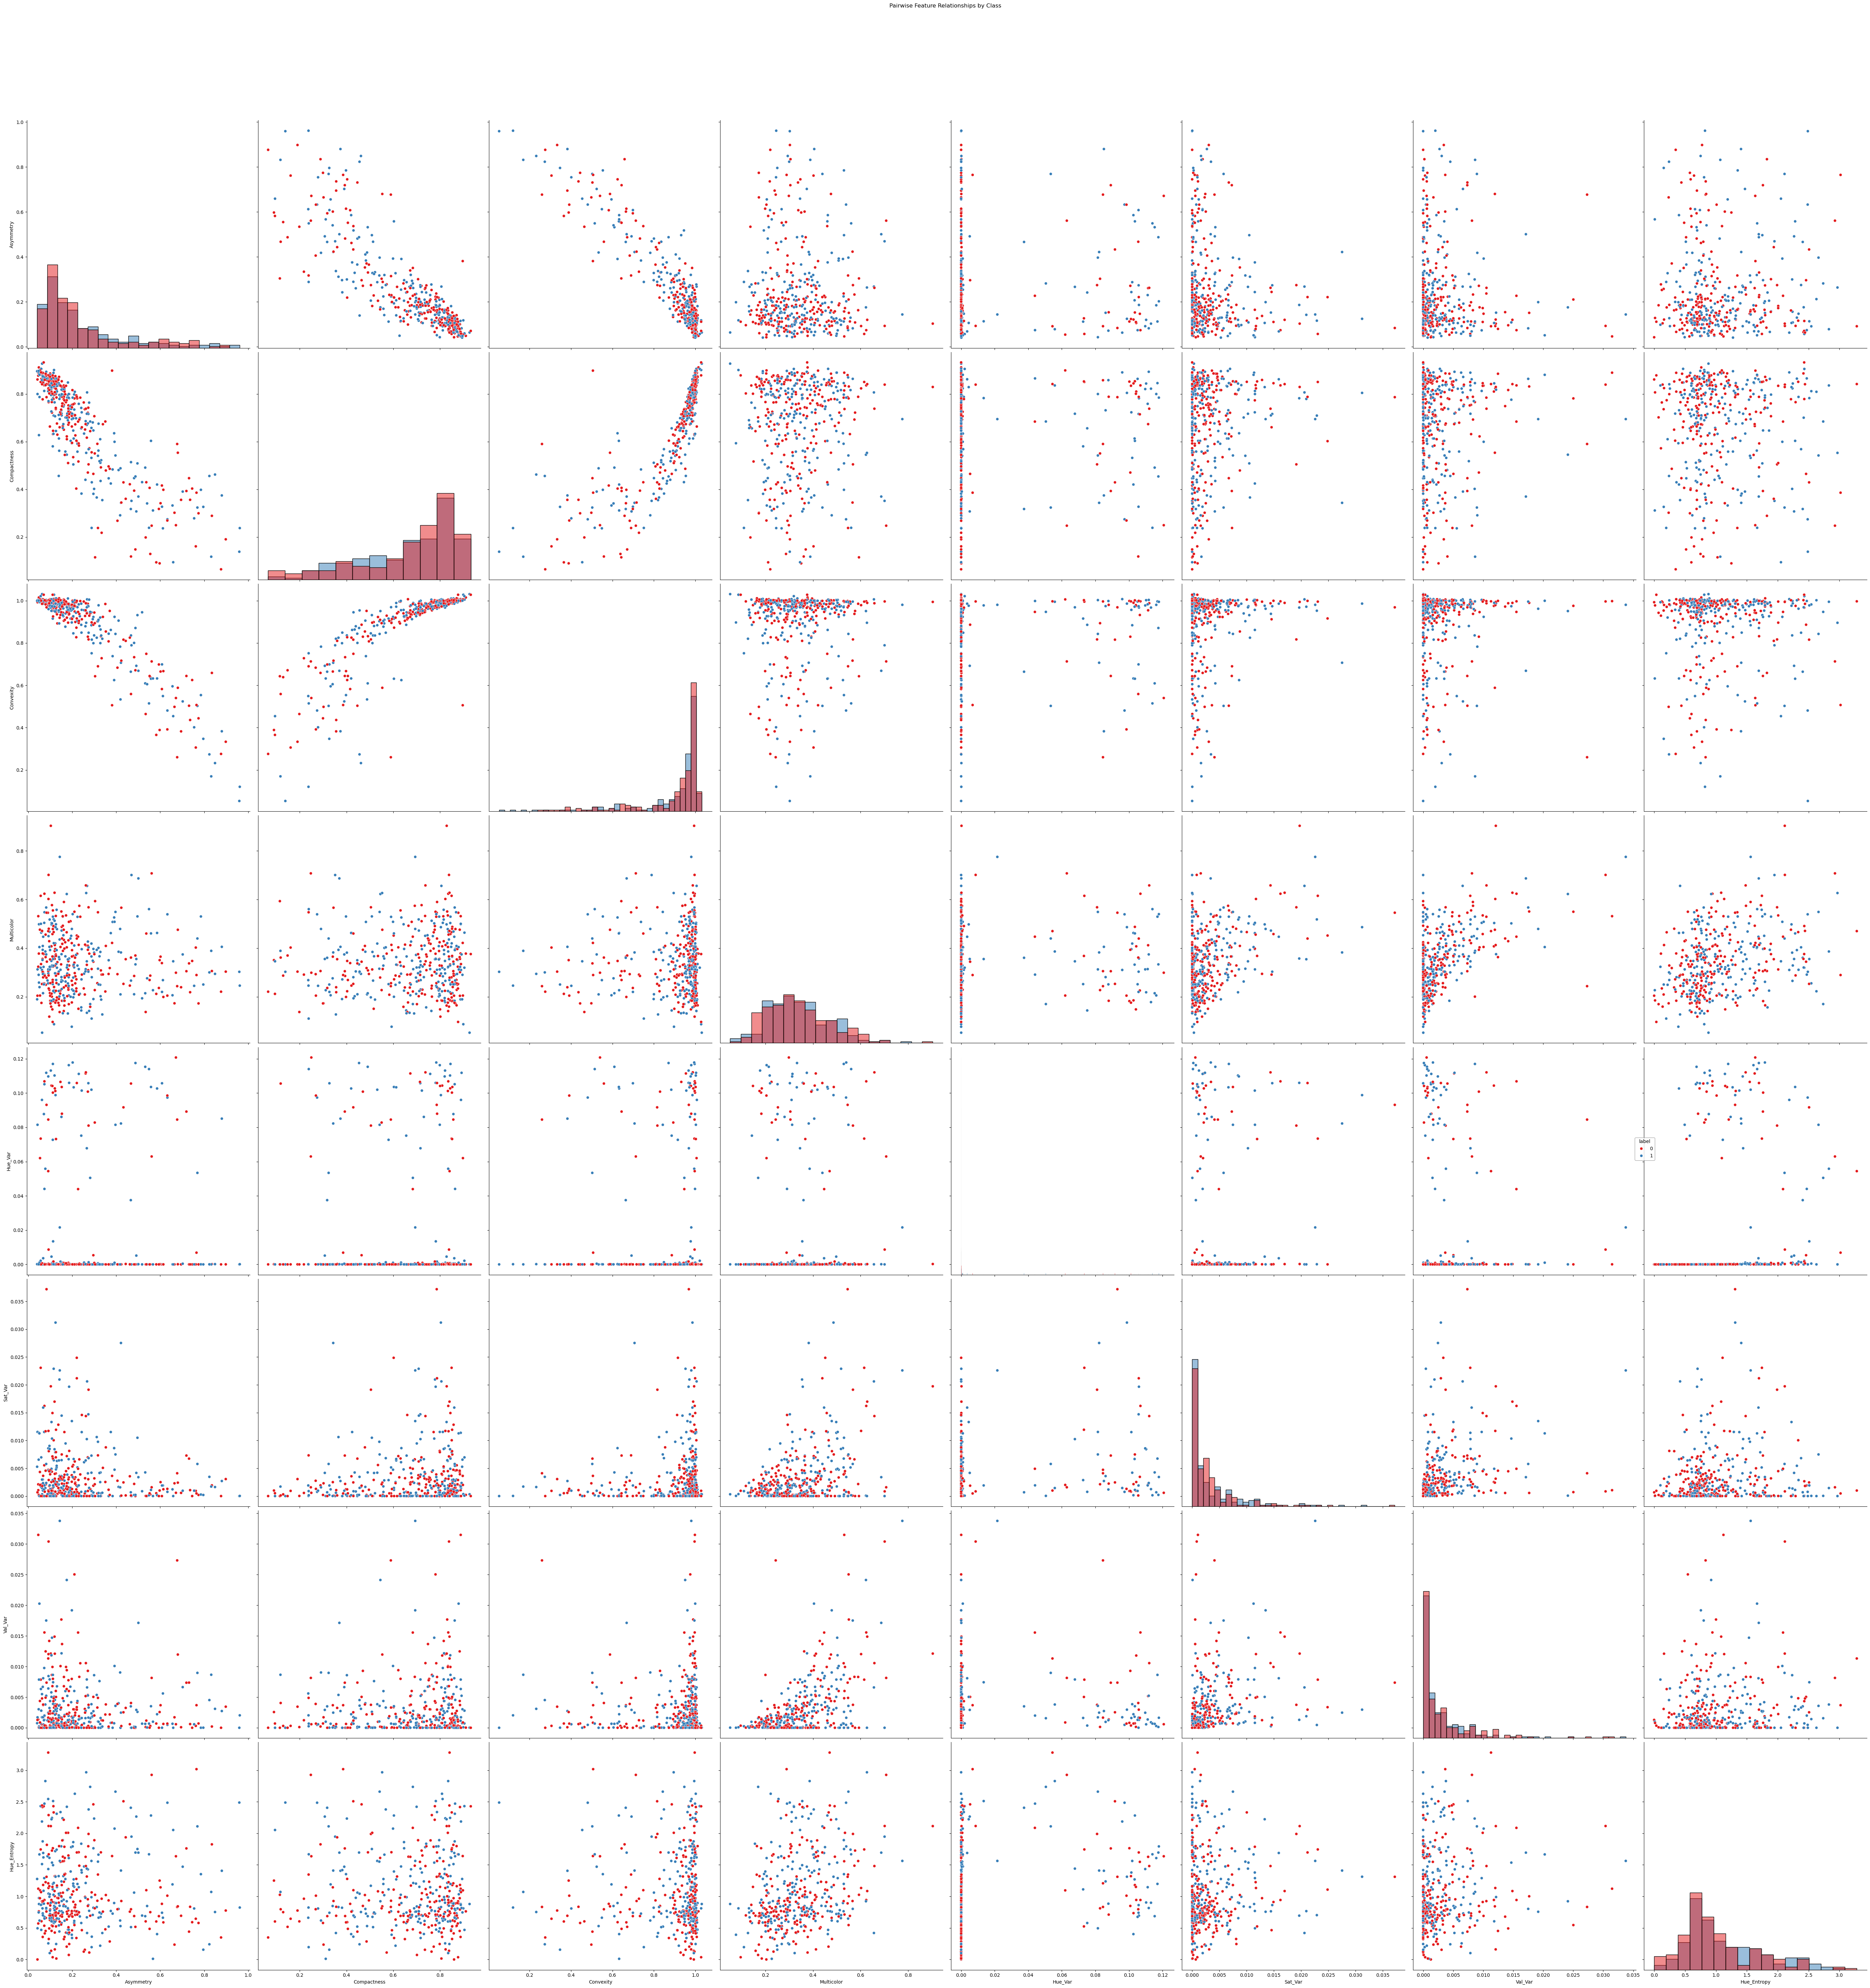

In [128]:
g = sns.pairplot(df, hue='label', palette="Set1", height=7, diag_kind="hist")

g.fig.suptitle("Pairwise Feature Relationships by Class", y=1.05)

g._legend.set_bbox_to_anchor((0.86, 0.44))

g._legend.set_frame_on(True)
frame = g._legend.get_frame()
frame.set_edgecolor("gray")
frame.set_linewidth(0.8)
frame.set_facecolor("white")

# create a label saying red is malignant and blue is benign


plt.show()

This above plot shows strong overlap between melanoma and non-melanoma classes across most features. Some correlations exist (like asymmetry and convexity), but individual features do not clearly separate the classes. This tells us that classification requires combining features or considering non linear classifier.

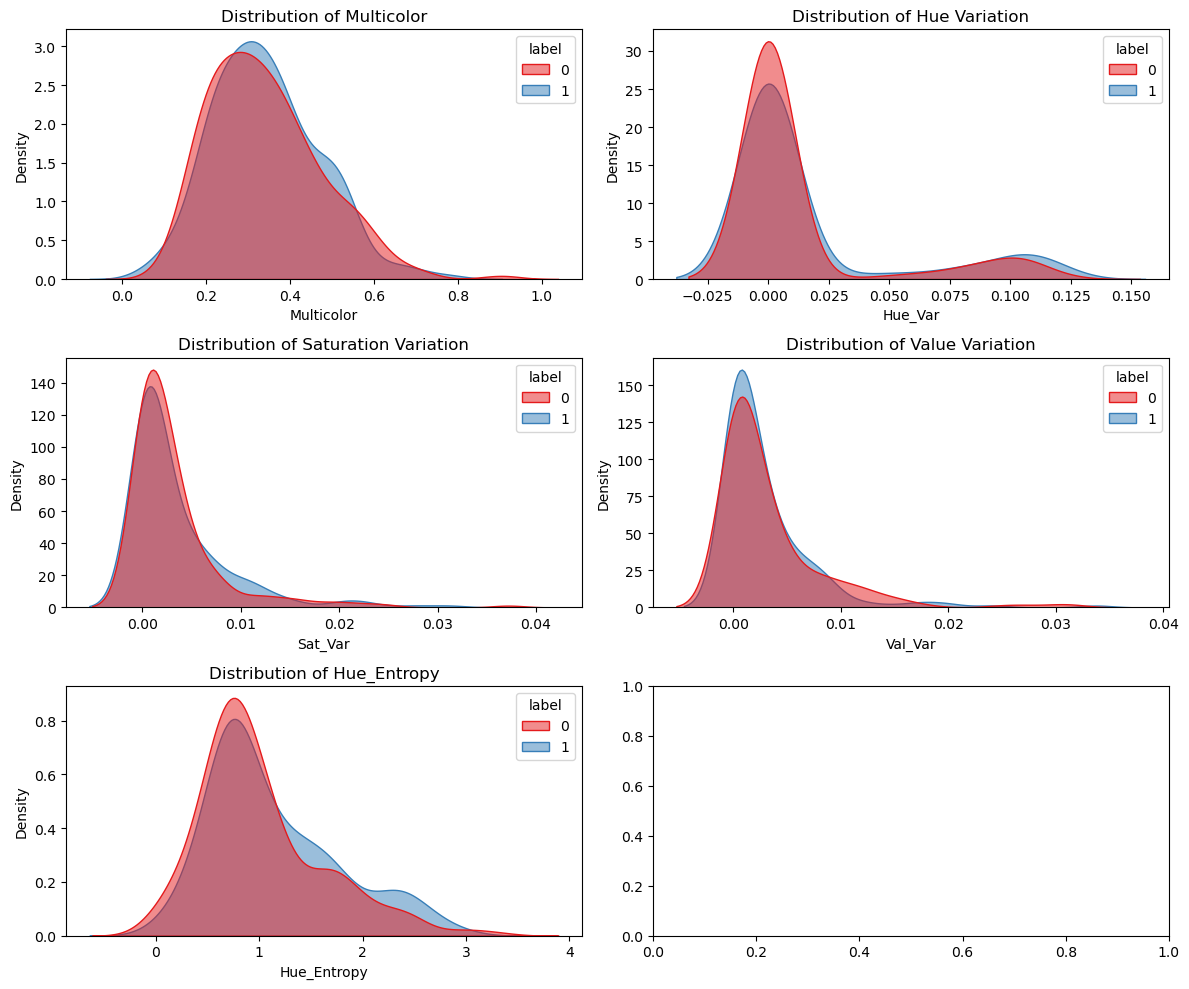

In [129]:
#Density plots for color features

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

sns.kdeplot(data=df, x="Multicolor", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Multicolor")
sns.kdeplot(data=df, x="Hue_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Hue Variation")
sns.kdeplot(data=df, x="Sat_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Saturation Variation")
sns.kdeplot(data=df, x="Val_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Value Variation")
sns.kdeplot(data=df, x="Hue_Entropy", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[2, 0])
axes[2, 0].set_title("Distribution of Hue_Entropy")

plt.tight_layout()
plt.show()



In [130]:
from sklearn.preprocessing import StandardScaler

# List of features I want to scale
color_features = ["Multicolor", "Hue_Var", "Sat_Var", "Val_Var", "Hue_Entropy"]

object = StandardScaler()

#Create a copy of df
df_scaled = df.copy()

# standardization 
df_scaled[color_features] = object.fit_transform(df[color_features])


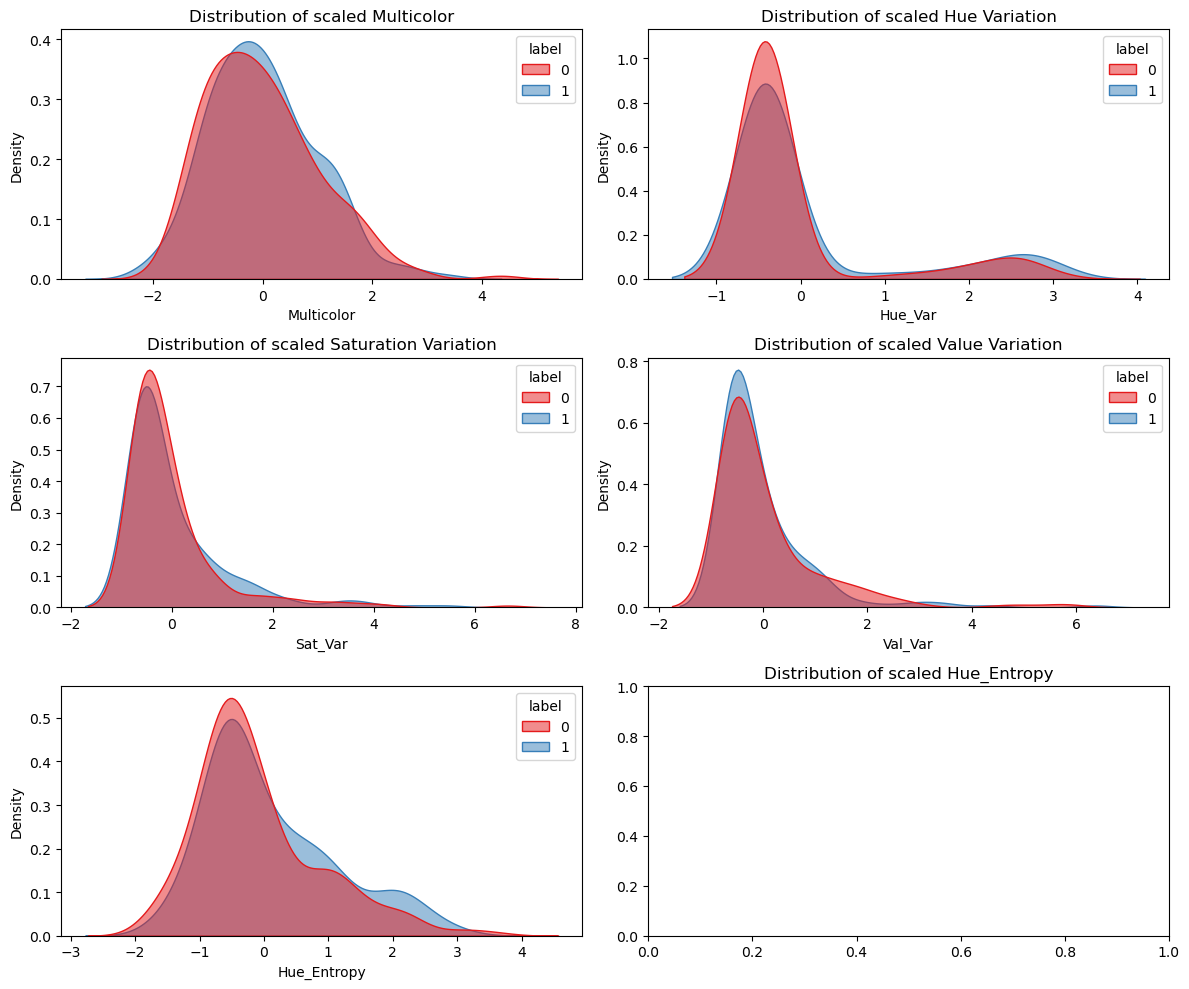

In [131]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

sns.kdeplot(data=df_scaled, x="Multicolor", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of scaled Multicolor")
sns.kdeplot(data=df_scaled, x="Hue_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of scaled Hue Variation")
sns.kdeplot(data=df_scaled, x="Sat_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of scaled Saturation Variation")
sns.kdeplot(data=df_scaled, x="Val_Var", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of scaled Value Variation")
sns.kdeplot(data=df_scaled, x="Hue_Entropy", hue="label", palette="Set1", fill= True, alpha= 0.5, common_norm=False, ax=axes[2, 0])
axes[2, 1].set_title("Distribution of scaled Hue_Entropy")

plt.tight_layout()
plt.show()

Standardizing the features centered the distributions at zero but did not improve class separation. This reveals that the overlap is not a result of different units across features, but rather is inbuilt to the data itself.

Text(0.5, 1.0, 'Feature distribution by label')

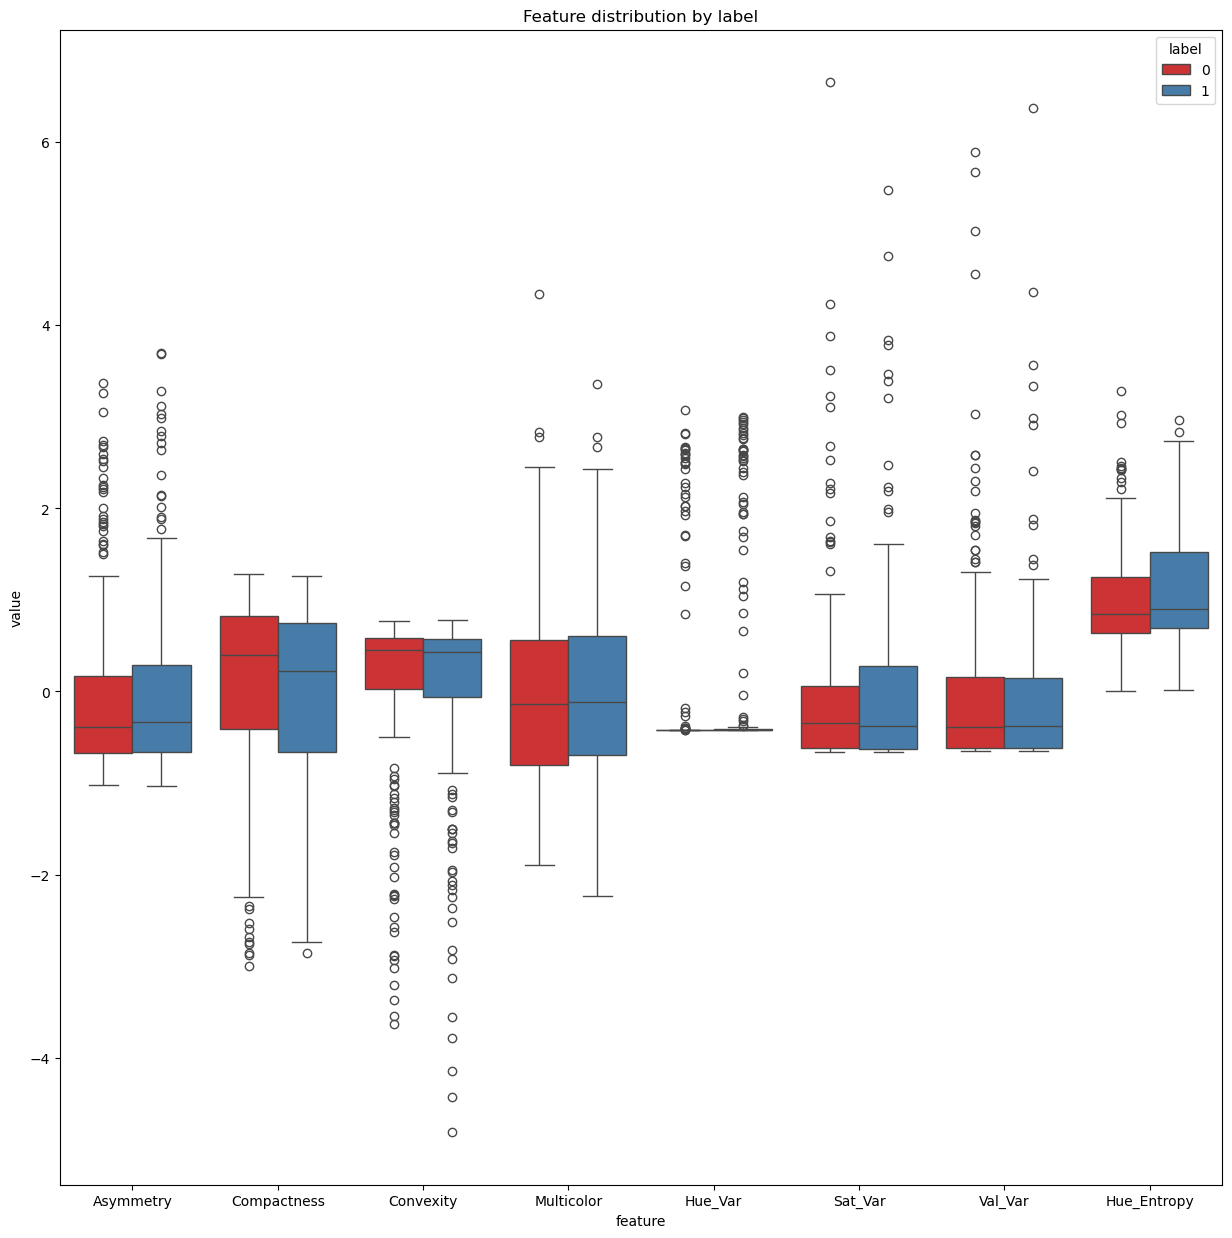

In [132]:
from sklearn.preprocessing import StandardScaler
 
# List of features I want to scale
features = ["Compactness","Asymmetry", "Convexity", "Multicolor", "Hue_Var", "Sat_Var", "Val_Var",]
object = StandardScaler()
 
#Create a copy of df
df_scaled = df.copy()
 
# standardization
df_scaled[features] = object.fit_transform(df[features])
df_scaled

long_df = df_scaled.melt(
    id_vars="label",
    var_name="feature",
    value_name="value"
)
long_df['value'] = pd.to_numeric(long_df['value'], errors='coerce')

plt.figure(figsize=(15, 15))
ax = sns.boxplot(data=long_df, x="feature", y="value", hue="label", palette="Set1")
ax.set_title("Feature distribution by label")


In [133]:
import plotly.express as px


df['label'] = df['label'].astype(str) 

features = ["Compactness", "Asymmetry", "Convexity", "Multicolor", "Hue_Var", "Sat_Var", "Val_Var", "Hue_Entropy"]

fig = px.scatter_3d(
    df, 
    x="Compactness", 
    y="Asymmetry", 
    z="Convexity",
    color="label",
    opacity=0.8,
    template="plotly_dark",
    title="Esploratore 3D - Punti Piccoli"
)


fig.update_traces(marker=dict(size=3, line=dict(width=0))) 

def create_buttons(axis_name):
    return [
        dict(
            method="restyle",
            args=[{axis_name: [df[f]]}],
            label=f
        ) for f in features
    ]

fig.update_layout(
    updatemenus=[
        dict(buttons=create_buttons("x"), direction="down", x=0.1, xanchor="left", y=1.1, yanchor="top"),
        dict(buttons=create_buttons("y"), direction="down", x=0.4, xanchor="left", y=1.1, yanchor="top"),
        dict(buttons=create_buttons("z"), direction="down", x=0.7, xanchor="left", y=1.1, yanchor="top")
    ]
)

fig.show()

Logistic Regression Accuracy: 45.88%
Random Forest Accuracy: 52.94%
KNN (k=7) Accuracy: 54.12%
Ensemble Accuracy: 55.29%


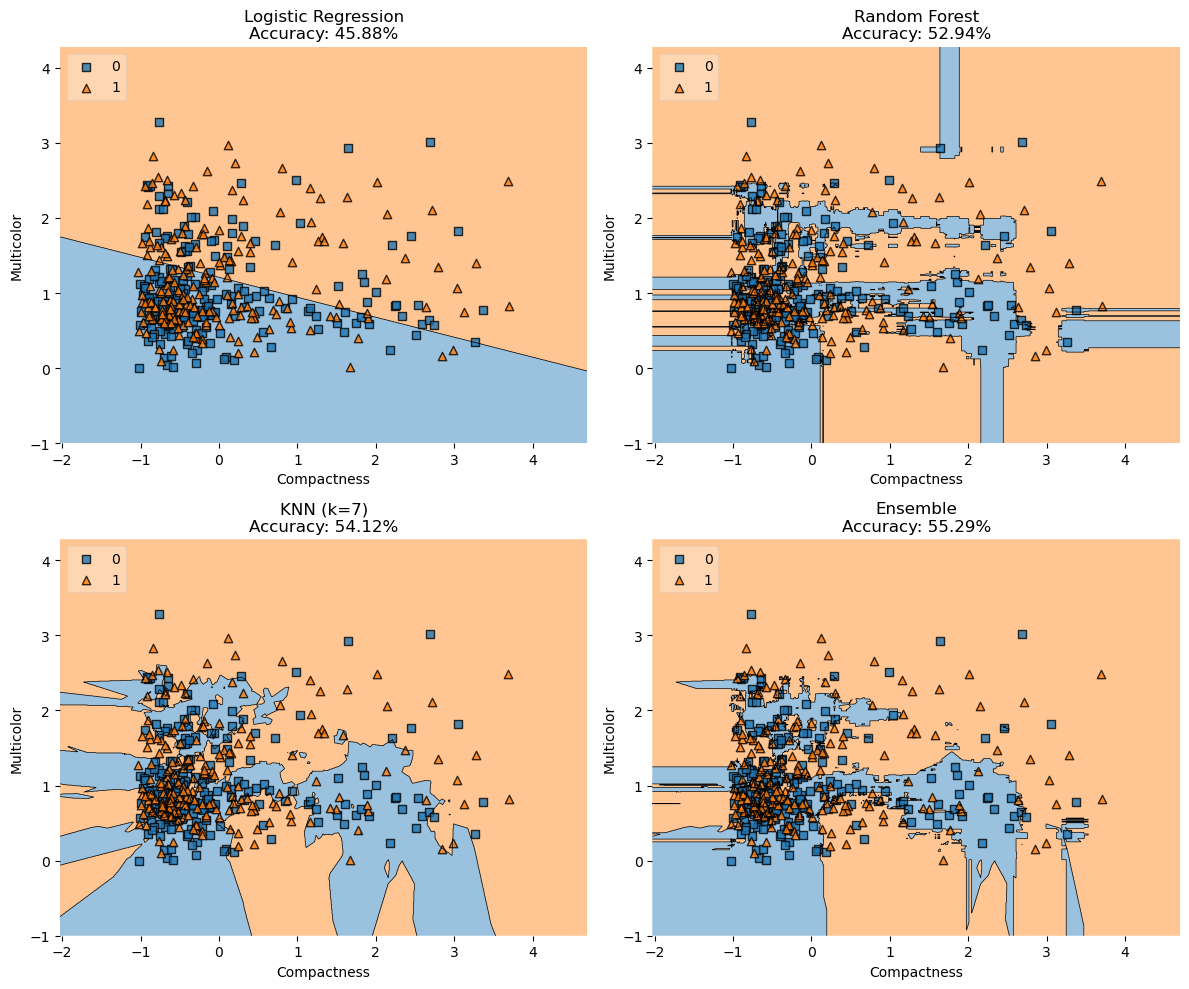

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mlxtend.classifier import EnsembleVoteClassifier
from mlxtend.plotting import plot_decision_regions

# 1. Feature Selection
# Column 1: Compactness, Column 3: Multicolor
X_subset = df_scaled.iloc[:, [0, 7]].values

# 2. Target Variable Preparation
# Converts 'True'/'False' strings into 1s and 0s
le = LabelEncoder()
y = le.fit_transform(df["label"]) 

# 3. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y, test_size=0.2, random_state=42
)

# 4. Initializing Classifiers
clf1 = LogisticRegression(random_state=0)
clf2 = RandomForestClassifier(random_state=0, n_estimators=100)
clf3 = KNeighborsClassifier(n_neighbors=7)
eclf = EnsembleVoteClassifier(clfs=[clf1, clf2, clf3],
                              weights=[0, 1, 1], voting='soft')

# 5. Plotting & Accuracy Setup
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12, 10))
labels = ['Logistic Regression', 'Random Forest', 'KNN (k=7)', 'Ensemble']

# 6. The Training, Accuracy, and Plotting Loop
for clf, lab, grd in zip([clf1, clf2, clf3, eclf],
                         labels,
                         itertools.product([0, 1], repeat=2)):
    
    # Train the model on the training data
    clf.fit(X_train, y_train)
    
    # Predict on the test data to get accuracy
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Print accuracy to the console
    print(f'{lab} Accuracy: {acc:.2%}')
    
    # Select the subplot
    ax = plt.subplot(gs[grd[0], grd[1]])
    
    # Plot the decision regions using the full dataset for visualization
    plot_decision_regions(X=X_subset, y=y, clf=clf, legend=2)
    
    # Add Title with Accuracy
    plt.title(f'{lab}\nAccuracy: {acc:.2%}')
    plt.xlabel('Compactness')
    plt.ylabel('Multicolor')

plt.tight_layout()
plt.show()

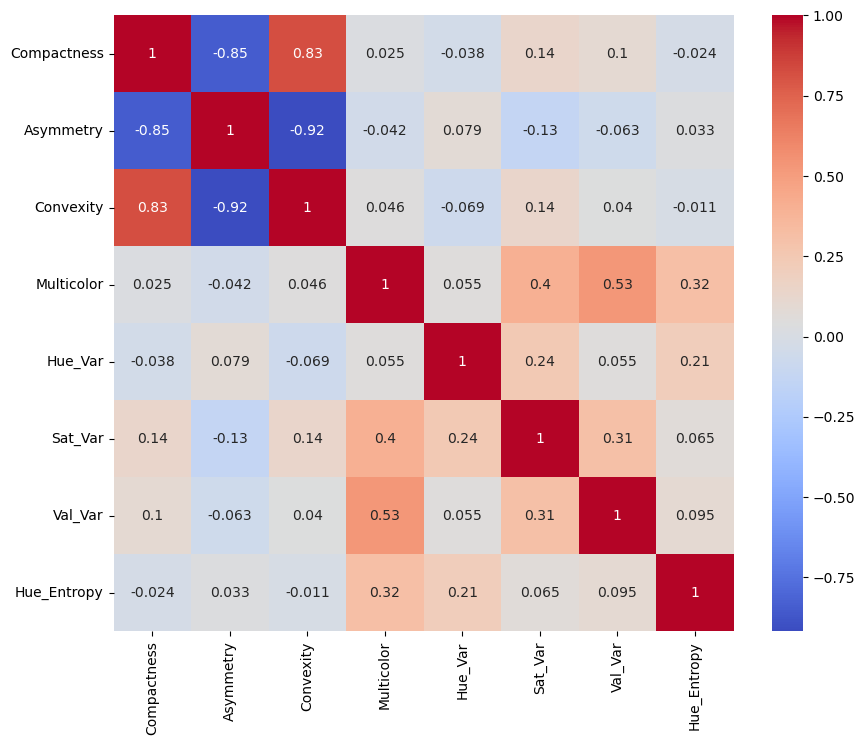

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
features_to_use = ["Compactness", "Asymmetry", "Convexity", "Multicolor", "Hue_Var", "Sat_Var", "Val_Var", "Hue_Entropy"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[features_to_use].corr(), annot=True, cmap='coolwarm')
plt.show()

In [136]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from mlxtend.classifier import EnsembleVoteClassifier

# change here the features you want to include
features_to_use = ["Hue_Var", "Sat_Var", "Val_Var", "Hue_Entropy"]


X = df[features_to_use].values 


le = LabelEncoder()
y = le.fit_transform(df["label"])

print(f"✅ Utilizzando {len(features_to_use)} features: {features_to_use}")


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


clf1 = LogisticRegression(random_state=0)
clf2 = RandomForestClassifier(n_estimators=100, random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=7)

eclf = EnsembleVoteClassifier(clfs=[clf1, clf2, clf3], voting='soft')


print("\n--- PERFORMANCE ---")
for clf, label in zip([clf1, clf2, clf3, eclf], 
                       ['Logistic Regression', 'Random Forest', 'KNN', 'Ensemble']):
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{label} Accuracy: {acc:.2%}')


print("\n--- REPORT  ---")
y_pred_eclf = eclf.predict(X_test)

print(classification_report(y_test, y_pred_eclf, target_names=le.classes_))

✅ Utilizzando 4 features: ['Hue_Var', 'Sat_Var', 'Val_Var', 'Hue_Entropy']

--- PERFORMANCE ---
Logistic Regression Accuracy: 52.94%
Random Forest Accuracy: 49.41%
KNN Accuracy: 47.06%
Ensemble Accuracy: 49.41%

--- REPORT  ---
              precision    recall  f1-score   support

           0       0.50      0.53      0.52        43
           1       0.49      0.45      0.47        42

    accuracy                           0.49        85
   macro avg       0.49      0.49      0.49        85
weighted avg       0.49      0.49      0.49        85

